# Week 2-3 Sold Dataset EDA

This notebook documents the Week 2-3 exploratory data analysis workflow for the CRMLS sold dataset.

Goals:
- Inspect rows, columns, and data types
- Review unique property types and Residential filtering logic
- Calculate missing counts and missing percentages
- Flag columns with more than 90% missing values
- Separate market analysis fields from metadata fields
- Review numeric distributions and outliers
- Save reports and a filtered analysis dataset

## 1. Import Packages And Set Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports" / "week2_3_sold_eda"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOLD_FILE = PROCESSED_DIR / "crmls_sold_combined_residential_202401_202606.csv"
SOLD_FILE

PosixPath('/Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/processed/crmls_sold_combined_residential_202401_202606.csv')

## 2. Load The Sold Dataset

This file was created in Week 1 by concatenating monthly sold CSVs and filtering to `PropertyType == "Residential"`.

In [2]:
sold = pd.read_csv(SOLD_FILE, low_memory=False)

# The combined Week 1 file is already filtered to Residential.
# Keep a separate name because the later EDA cells use sold_residential.
sold_residential = sold.copy()

print(f"Rows: {sold_residential.shape[0]:,}")
print(f"Columns: {sold_residential.shape[1]:,}")
sold_residential.head()


Rows: 447,991
Columns: 82


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,NaN,NaN,NaN,NaN
4,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,2.0,NaN,95437,NaN,74487.6,NaN,NaN,NaN,NaN,NaN


## 3. Inspect Structure

In [3]:
sold.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [4]:
dtypes_summary = sold.dtypes.astype(str).reset_index()
dtypes_summary.columns = ["column", "dtype"]
dtypes_summary

,column,dtype
0,Flooring,str
1,ViewYN,object
2,WaterfrontYN,object
3,BasementYN,object
4,PoolPrivateYN,object
...,...,...
77,MiddleOrJuniorSchoolDistrict,float64
78,BuyerAgentAOR,str
79,ListAgentAOR,str
80,OriginatingSystemName,str


## 4. Review Property Types

Because this processed file is already Residential-filtered, we expect only Residential rows here. If you need Residential vs. other property type share, use the raw monthly sold files or save an unfiltered combined sold dataset.

In [5]:
property_type_counts = sold["PropertyType"].fillna("Missing").value_counts(dropna=False)
property_type_counts

PropertyType
Residential    447991
Name: count, dtype: int64

## 5. Missing Value Analysis

In [6]:
missing_report = pd.DataFrame({
    "column": sold_residential.columns,
    "missing_count": sold_residential.isna().sum().values,
})

missing_report["missing_pct"] = (
    missing_report["missing_count"] / len(sold_residential) * 100
).round(2)
missing_report["over_90_pct_missing"] = missing_report["missing_pct"] > 90
missing_report = missing_report.sort_values("missing_pct", ascending=False)

missing_report.head(25)

,column,missing_count,missing_pct,over_90_pct_missing
55,ElementarySchoolDistrict,447991,100.00,True
33,TaxAnnualAmount,447991,100.00,True
51,TaxYear,447991,100.00,True
28,FireplacesTotal,447991,100.00,True
60,BusinessType,447991,100.00,True
62,CoveredSpaces,447991,100.00,True
77,MiddleOrJuniorSchoolDistrict,447991,100.00,True
30,AboveGradeFinishedArea,447991,100.00,True
2,WaterfrontYN,447704,99.94,True
59,BelowGradeFinishedArea,445335,99.41,True


In [7]:
high_missing_columns = missing_report[missing_report["over_90_pct_missing"]]
high_missing_columns

,column,missing_count,missing_pct,over_90_pct_missing
55,ElementarySchoolDistrict,447991,100.00,True
33,TaxAnnualAmount,447991,100.00,True
51,TaxYear,447991,100.00,True
28,FireplacesTotal,447991,100.00,True
60,BusinessType,447991,100.00,True
62,CoveredSpaces,447991,100.00,True
77,MiddleOrJuniorSchoolDistrict,447991,100.00,True
30,AboveGradeFinishedArea,447991,100.00,True
2,WaterfrontYN,447704,99.94,True
59,BelowGradeFinishedArea,445335,99.41,True


## 6. Market Analysis Fields Vs Metadata Fields

This is a first-pass field classification. Core market fields should usually be retained even if they have some missing values.

In [8]:
core_market_fields = {
    "ListingKey", "ListingId", "CloseDate", "ClosePrice", "ListPrice",
    "OriginalListPrice", "PropertyType", "PropertySubType", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket",
    "YearBuilt", "CountyOrParish", "City", "PostalCode", "Latitude",
    "Longitude", "ListingContractDate", "PurchaseContractDate",
}

metadata_fields = {
    "ListingKeyNumeric", "ListAgentEmail", "ListAgentFirstName",
    "ListAgentLastName", "ListAgentFullName", "CoListAgentFirstName",
    "CoListAgentLastName", "CoBuyerAgentFirstName", "BuyerAgentMlsId",
    "BuyerAgentFirstName", "BuyerAgentLastName", "ListOfficeName",
    "BuyerOfficeName", "CoListOfficeName", "BuyerOfficeAOR",
    "BuyerAgentAOR", "ListAgentAOR", "OriginatingSystemName",
    "OriginatingSystemSubName", "MlsStatus",
}

field_classification = []
for column in sold_residential.columns:
    if column in metadata_fields:
        category = "metadata"
    elif column in core_market_fields:
        category = "market_analysis_core"
    else:
        category = "market_analysis_other"
    field_classification.append({"column": column, "field_category": category})

field_classification = pd.DataFrame(field_classification)
field_classification

,column,field_category
0,Flooring,market_analysis_other
1,ViewYN,market_analysis_other
2,WaterfrontYN,market_analysis_other
3,BasementYN,market_analysis_other
4,PoolPrivateYN,market_analysis_other
...,...,...
77,MiddleOrJuniorSchoolDistrict,market_analysis_other
78,BuyerAgentAOR,metadata
79,ListAgentAOR,metadata
80,OriginatingSystemName,metadata


## 7. Numeric Distribution Summary

In [9]:
numeric_fields = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt",
]

numeric_summary_rows = []

for field in numeric_fields:
    series = pd.to_numeric(sold_residential[field], errors="coerce")
    percentiles = series.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    numeric_summary_rows.append({
        "field": field,
        "count": int(series.count()),
        "missing_count": int(series.isna().sum()),
        "min": series.min(),
        "max": series.max(),
        "mean": series.mean(),
        "median": series.median(),
        "p01": percentiles.loc[0.01],
        "p05": percentiles.loc[0.05],
        "p25": percentiles.loc[0.25],
        "p50": percentiles.loc[0.5],
        "p75": percentiles.loc[0.75],
        "p95": percentiles.loc[0.95],
        "p99": percentiles.loc[0.99],
    })

numeric_summary = pd.DataFrame(numeric_summary_rows)
numeric_summary

,field,count,missing_count,min,max,mean,median,p01,p05,p25,p50,p75,p95,p99
0,ClosePrice,447989,2,0.0,9.895000e+08,1.192647e+06,825000.0000,200594.6,340000.00,575000.00,825000.0000,1.300000e+06,2.858000e+06,5.600000e+06
1,ListPrice,447991,0,525.0,1.375000e+08,1.143454e+06,819000.0000,213885.0,345000.00,578000.00,819000.0000,1.295000e+06,2.875000e+06,5.750000e+06
2,OriginalListPrice,447172,819,0.0,1.390000e+09,1.228612e+06,829000.0000,210000.0,349900.00,585000.00,829000.0000,1.299000e+06,2.900000e+06,5.995000e+06
3,LivingArea,447738,253,0.0,1.702132e+07,1.904285e+03,1646.0000,605.0,840.00,1248.00,1646.0000,2.224000e+03,3.564000e+03,5.288000e+03
4,LotSizeAcres,413252,34739,0.0,7.810698e+06,6.203670e+01,0.1666,0.0,0.03,0.12,0.1666,2.743000e-01,2.860700e+00,1.088920e+01
5,BedroomsTotal,447979,12,0.0,4.500000e+01,3.205224e+00,3.0000,1.0,2.00,3.00,3.0000,4.000000e+00,5.000000e+00,6.000000e+00
6,BathroomsTotalInteger,447921,70,0.0,1.750000e+02,2.538463e+00,2.0000,1.0,1.00,2.00,2.0000,3.000000e+00,4.000000e+00,6.000000e+00
7,DaysOnMarket,447991,0,-288.0,1.243000e+04,3.731455e+01,18.0000,0.0,1.00,8.00,18.0000,4.800000e+01,1.320000e+02,2.330000e+02
8,YearBuilt,447591,400,1776.0,2.027000e+03,1.978616e+03,1979.0000,1912.0,1930.00,1960.00,1979.0000,1.999000e+03,2.022000e+03,2.025000e+03


## 8. Histograms And Boxplots

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


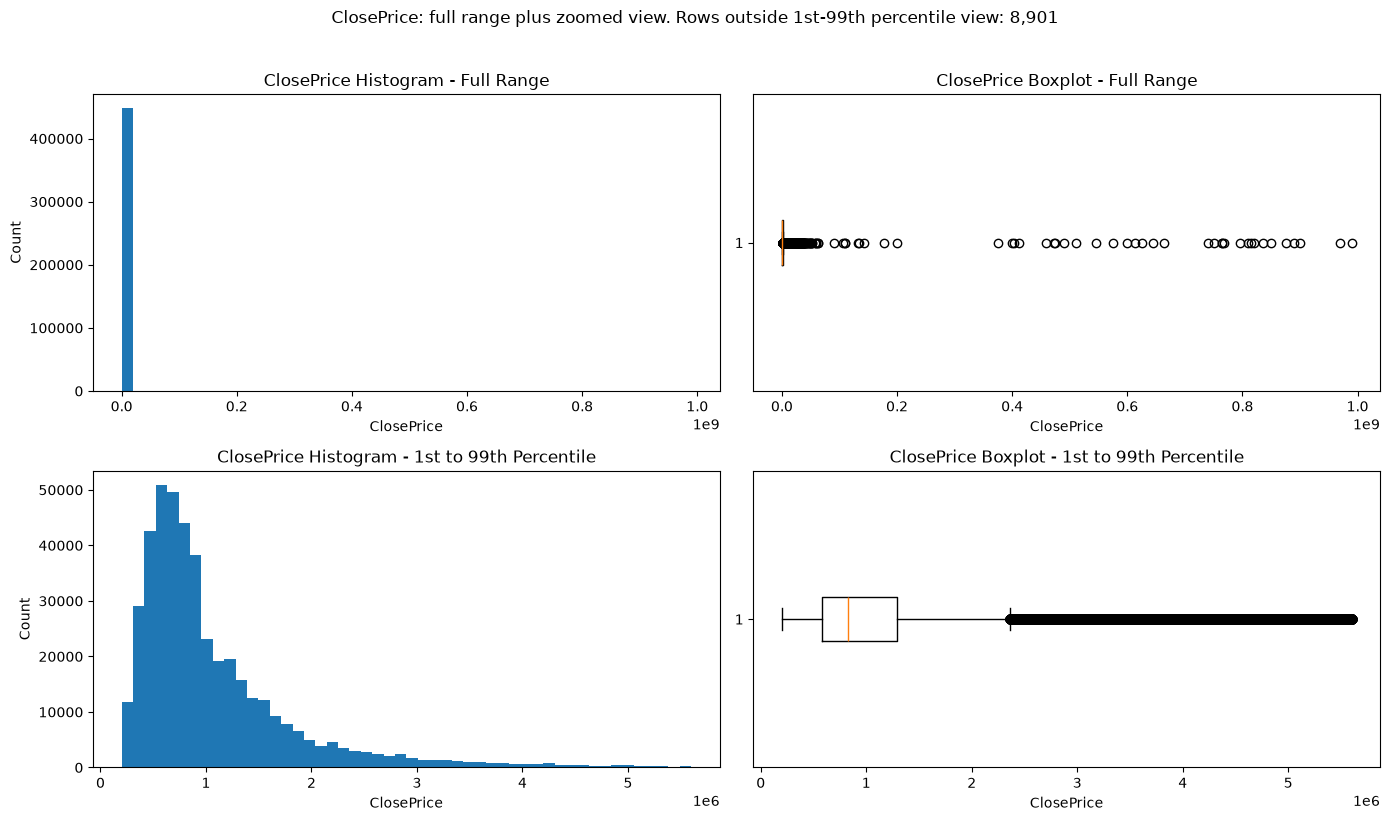

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


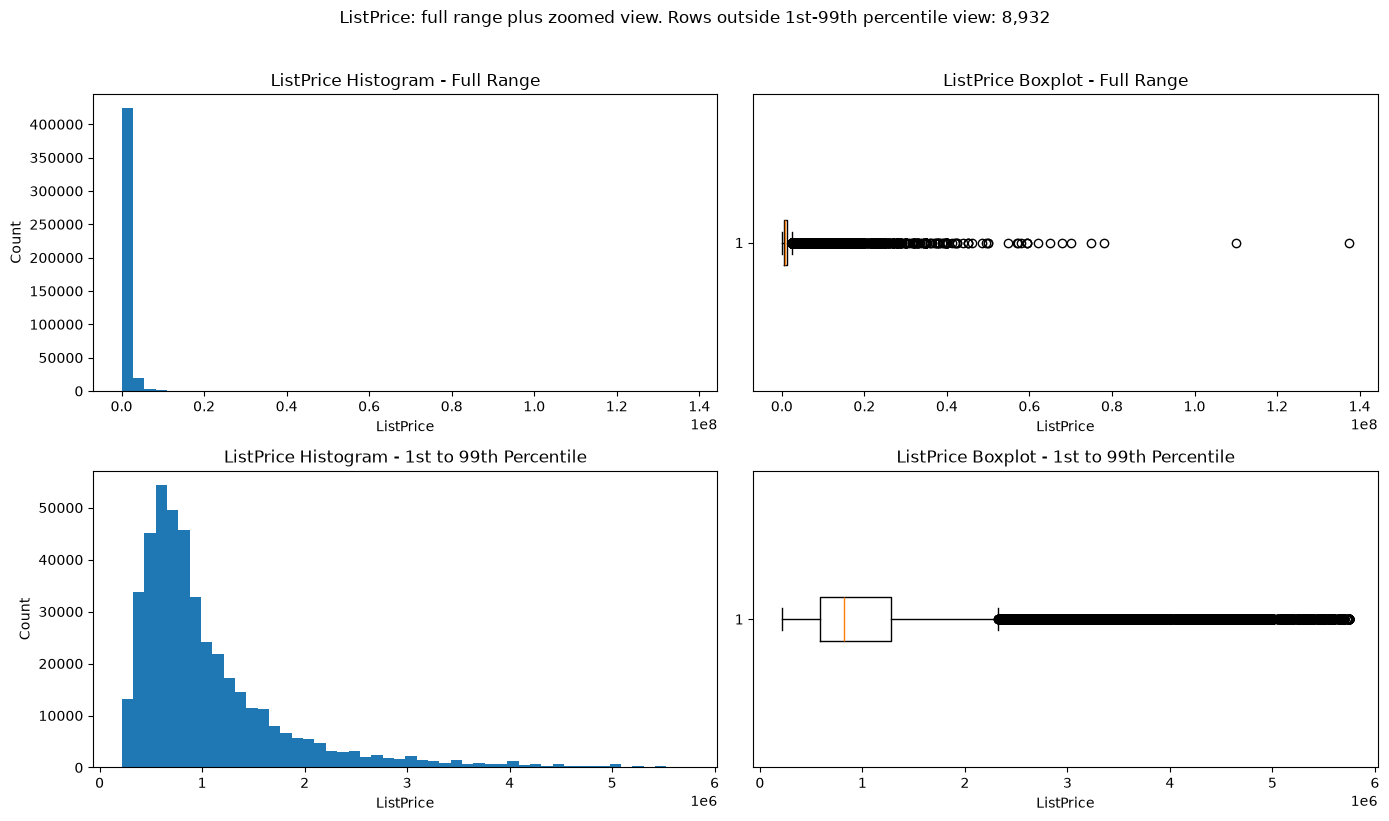

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


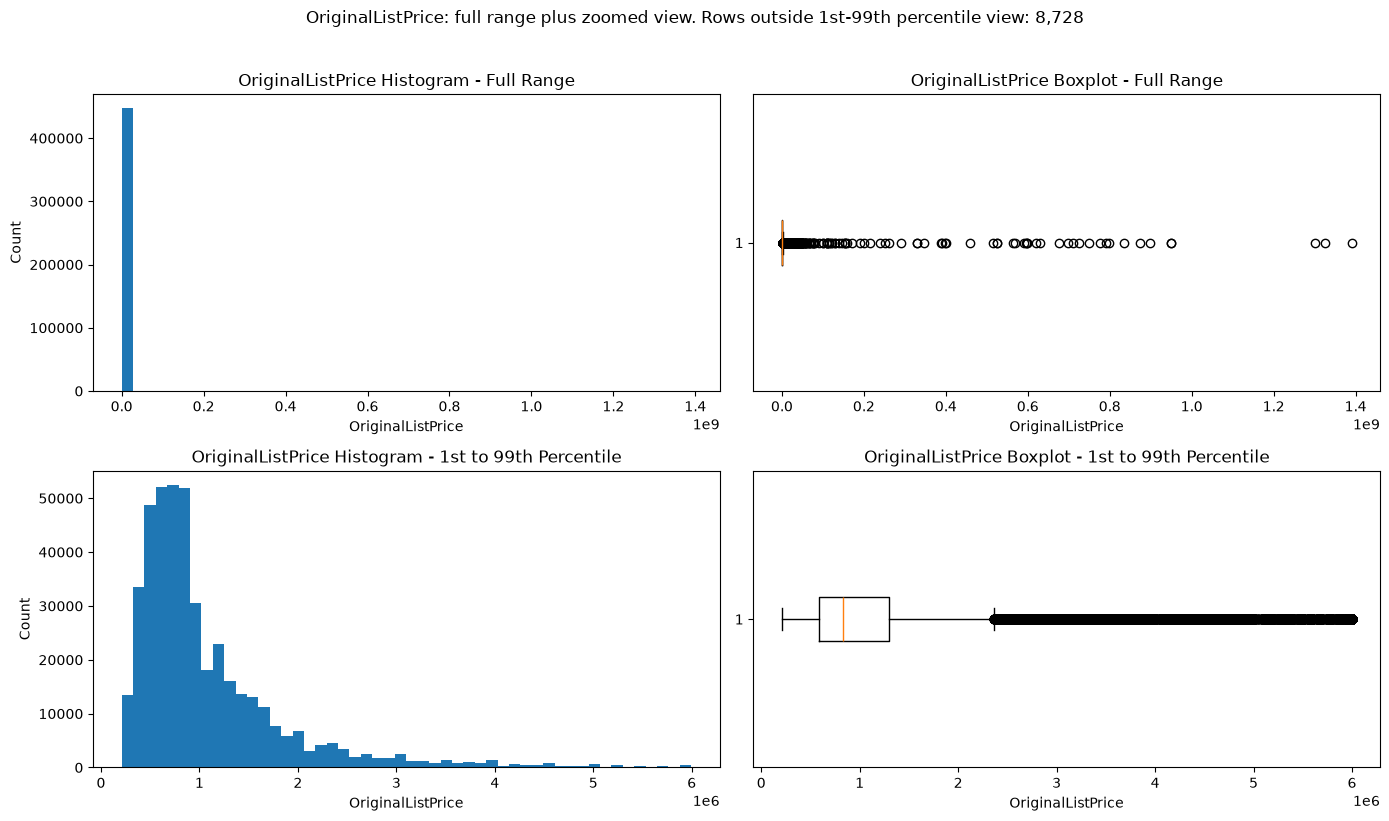

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


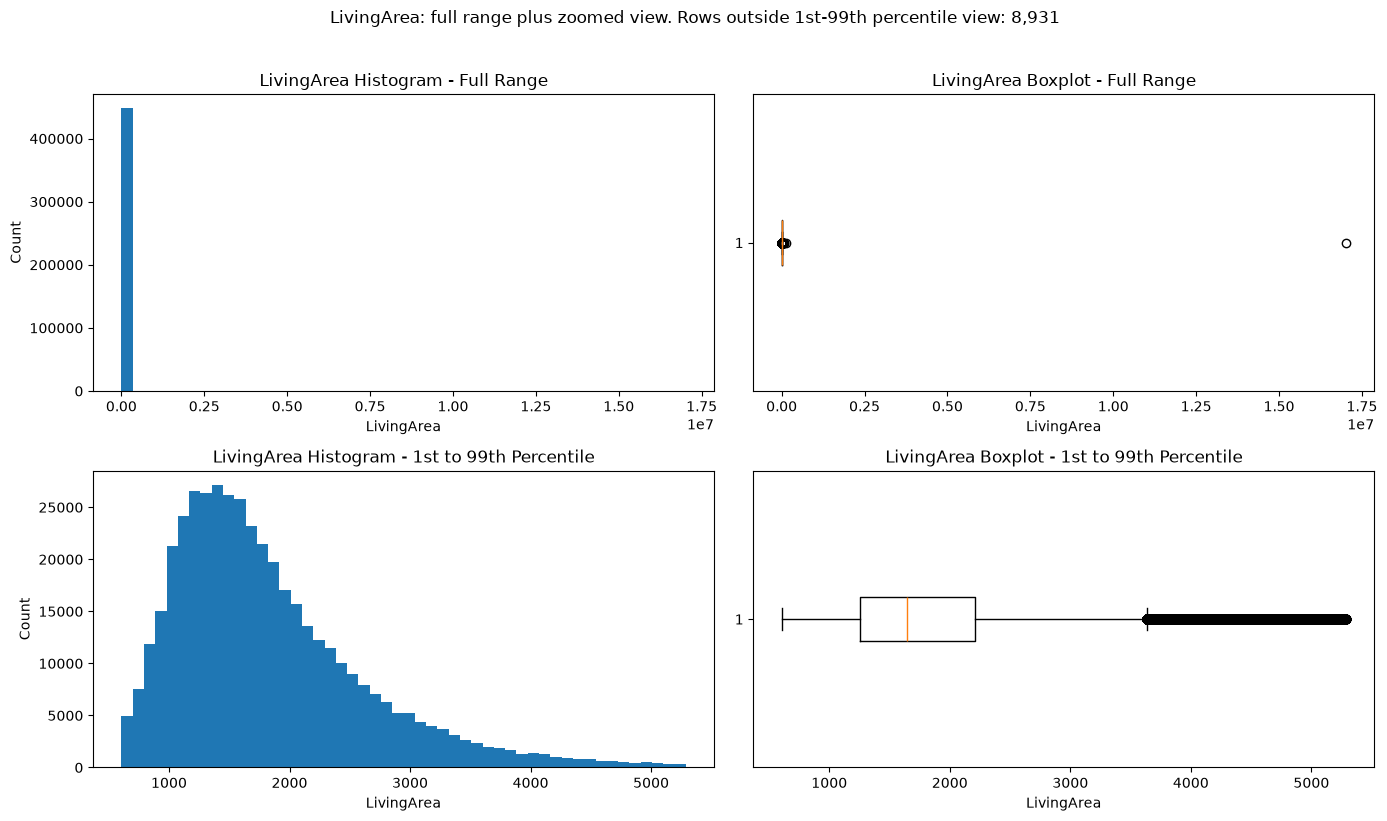

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


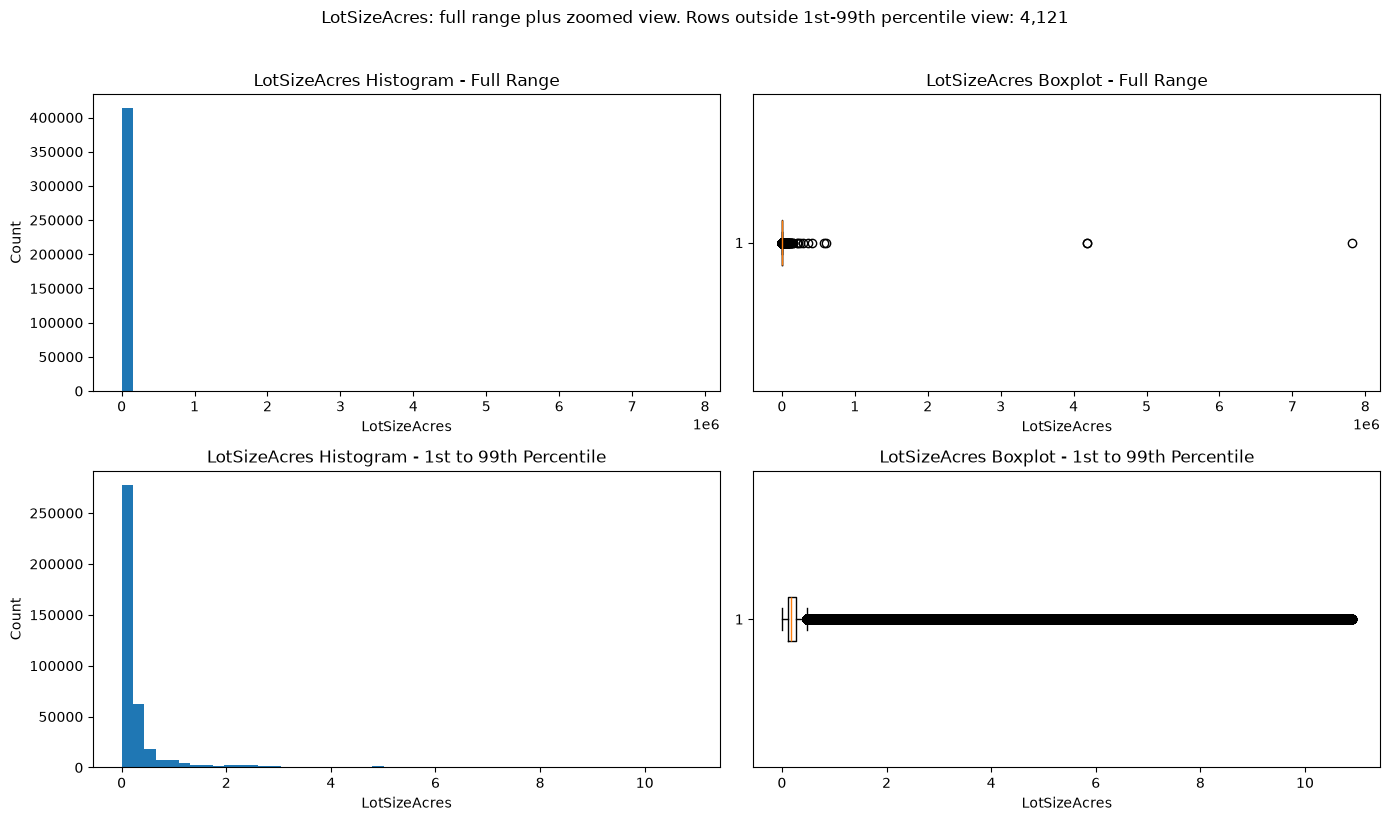

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


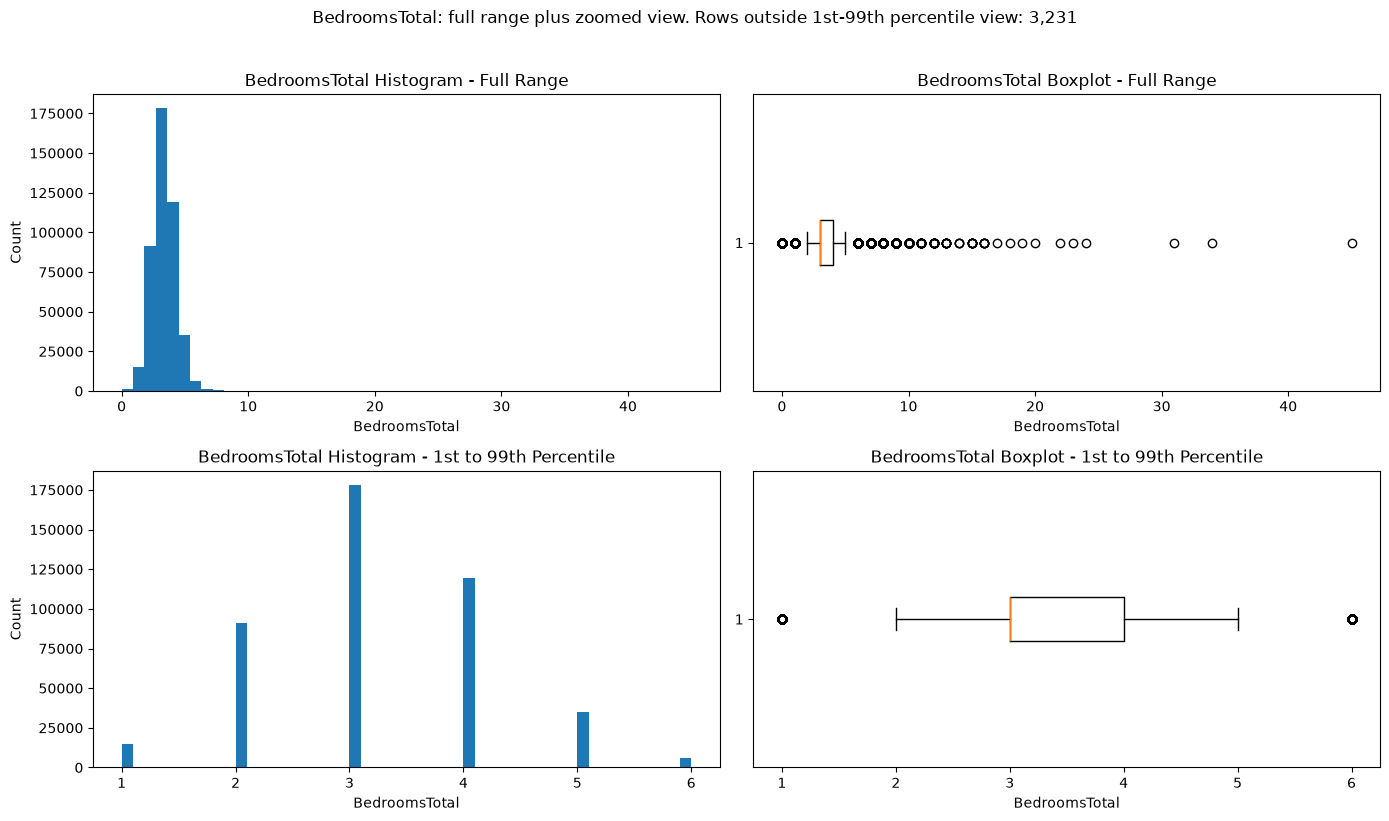

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


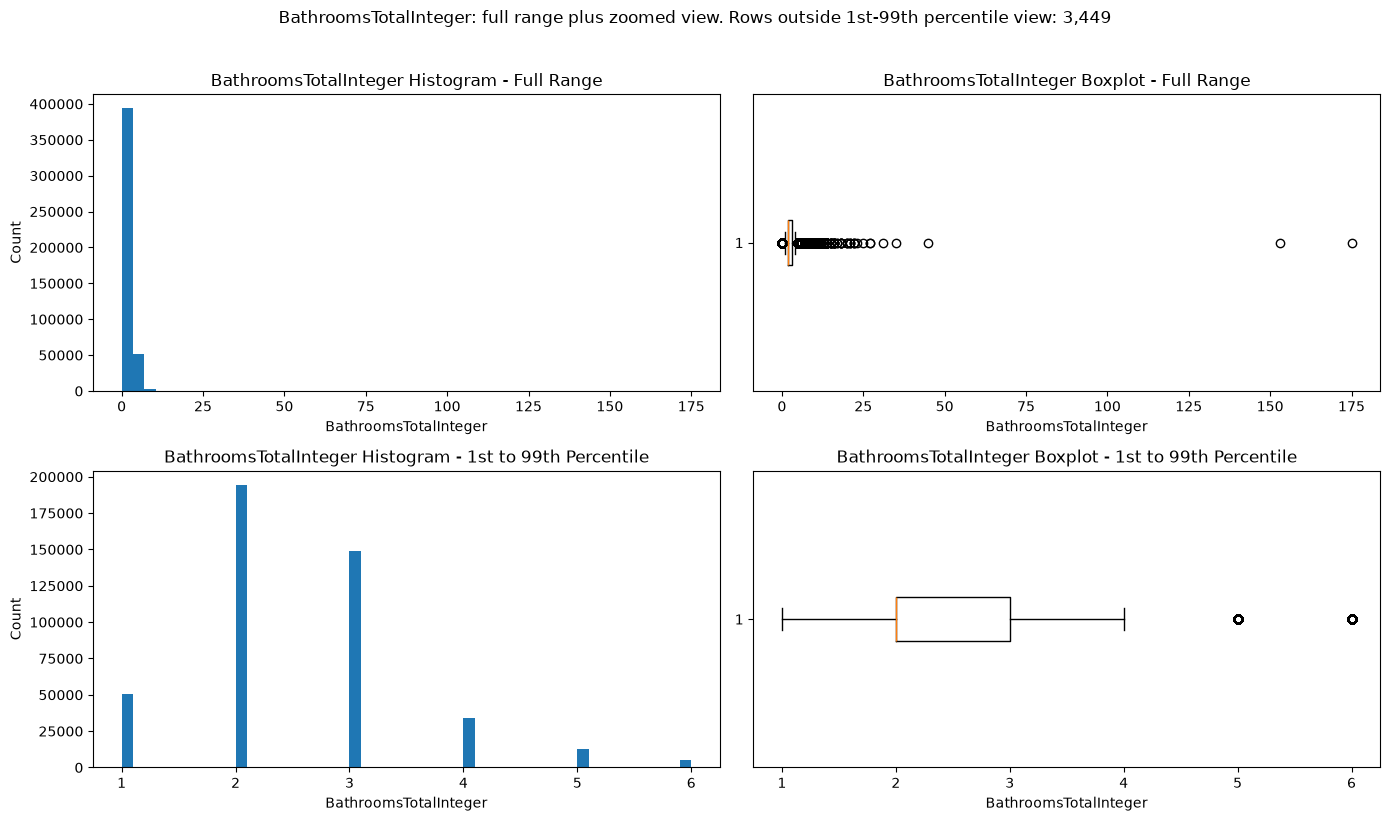

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


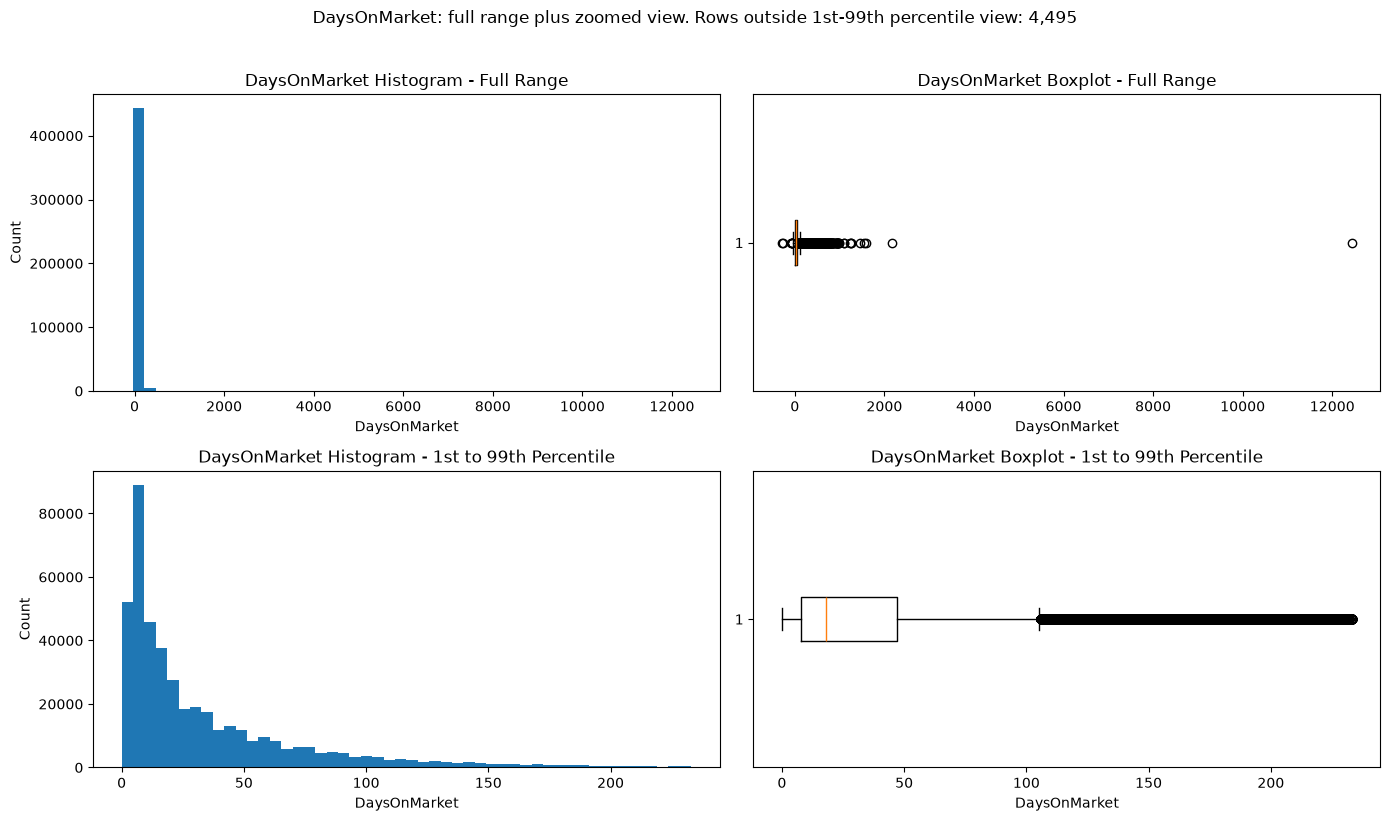

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_29759/765245606.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


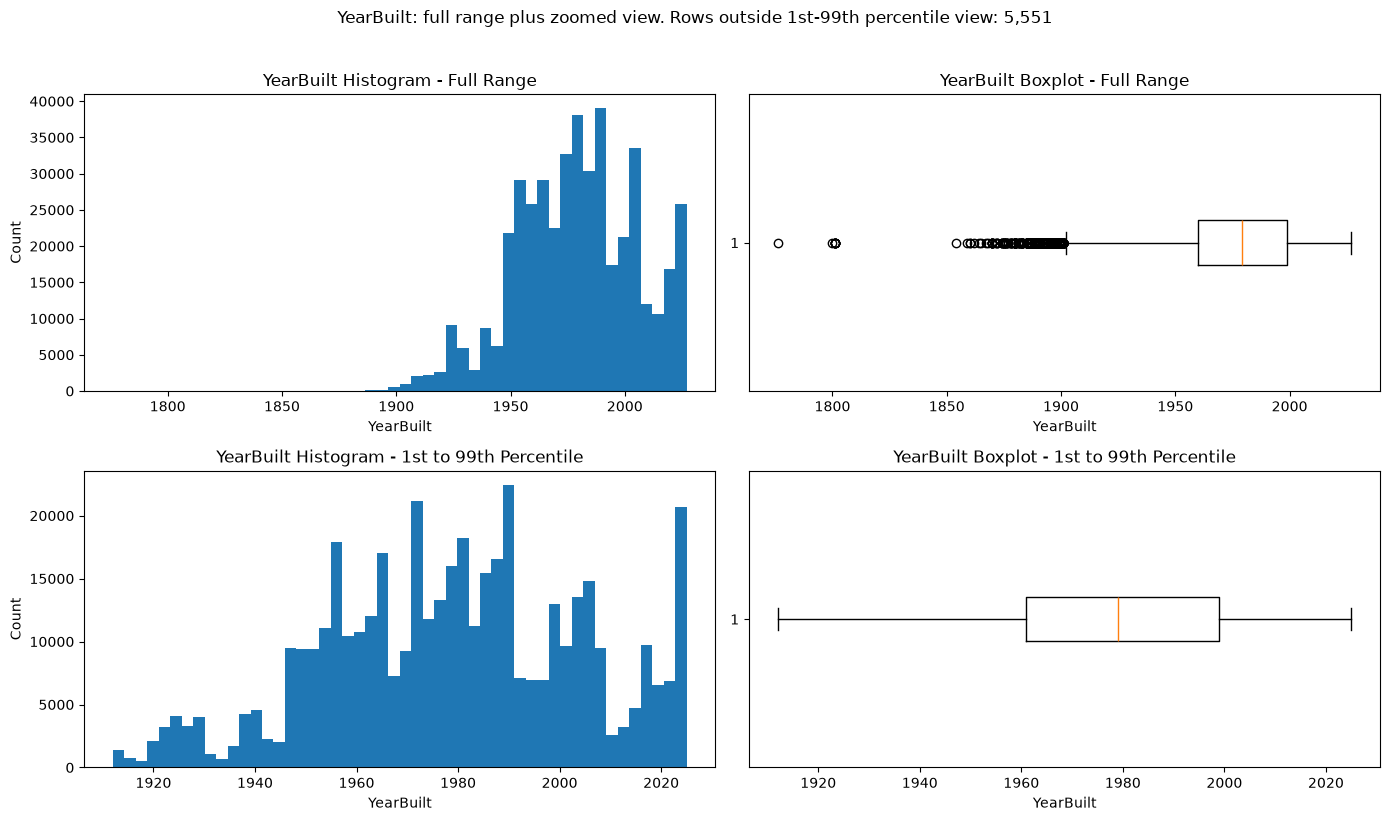

In [10]:
for field in numeric_fields:
    series = pd.to_numeric(sold_residential[field], errors="coerce").dropna()
    if series.empty:
        continue

    p01 = series.quantile(0.01)
    p99 = series.quantile(0.99)
    zoomed_series = series[(series >= p01) & (series <= p99)]
    outside_zoom_count = len(series) - len(zoomed_series)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].hist(series, bins=50)
    axes[0, 0].set_title(f"{field} Histogram - Full Range")
    axes[0, 0].set_xlabel(field)
    axes[0, 0].set_ylabel("Count")

    axes[0, 1].boxplot(series, vert=False, showfliers=True)
    axes[0, 1].set_title(f"{field} Boxplot - Full Range")
    axes[0, 1].set_xlabel(field)

    axes[1, 0].hist(zoomed_series, bins=50)
    axes[1, 0].set_title(f"{field} Histogram - 1st to 99th Percentile")
    axes[1, 0].set_xlabel(field)
    axes[1, 0].set_ylabel("Count")

    axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)
    axes[1, 1].set_title(f"{field} Boxplot - 1st to 99th Percentile")
    axes[1, 1].set_xlabel(field)

    fig.suptitle(
        f"{field}: full range plus zoomed view. "
        f"Rows outside 1st-99th percentile view: {outside_zoom_count:,}",
        y=1.02,
    )

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{field}_full_and_zoomed_histogram_boxplot.png")
    plt.show()

## 9. Extreme Outlier Review

This uses the IQR rule to identify values outside `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`. These are not automatically removed; they are flagged for later cleaning decisions.

In [11]:
outlier_rows = []

for field in numeric_fields:
    series = pd.to_numeric(sold_residential[field], errors="coerce").dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    low_outliers = int((series < lower_bound).sum())
    high_outliers = int((series > upper_bound).sum())
    
    outlier_rows.append({
        "field": field,
        "iqr_lower_bound": lower_bound,
        "iqr_upper_bound": upper_bound,
        "low_outlier_count": low_outliers,
        "high_outlier_count": high_outliers,
        "total_outlier_count": low_outliers + high_outliers,
        "outlier_pct": round((low_outliers + high_outliers) / len(series) * 100, 2),
        "min": series.min(),
        "max": series.max(),
    })

outlier_report = pd.DataFrame(outlier_rows)
outlier_report

,field,iqr_lower_bound,iqr_upper_bound,low_outlier_count,high_outlier_count,total_outlier_count,outlier_pct,min,max
0,ClosePrice,-512500.00000,2.387500e+06,0,33539,33539,7.49,0.0,9.895000e+08
1,ListPrice,-497500.00000,2.370500e+06,0,33838,33838,7.55,525.0,1.375000e+08
2,OriginalListPrice,-486000.00000,2.370000e+06,0,35115,35115,7.85,0.0,1.390000e+09
3,LivingArea,-216.00000,3.688000e+03,0,19567,19567,4.37,0.0,1.702132e+07
4,LotSizeAcres,-0.11145,5.057500e-01,0,64260,64260,15.55,0.0,7.810698e+06
5,BedroomsTotal,1.50000,5.500000e+00,16361,8150,24511,5.47,0.0,4.500000e+01
6,BathroomsTotalInteger,0.50000,4.500000e+00,346,20414,20760,4.63,0.0,1.750000e+02
7,DaysOnMarket,-52.00000,1.080000e+02,8,34172,34180,7.63,-288.0,1.243000e+04
8,YearBuilt,1901.50000,2.057500e+03,1062,0,1062,0.24,1776.0,2.027000e+03


## 10. Answer EDA Questions

In [12]:
close_price = pd.to_numeric(sold_residential["ClosePrice"], errors="coerce")
list_price = pd.to_numeric(sold_residential["ListPrice"], errors="coerce")
days_on_market = pd.to_numeric(sold_residential["DaysOnMarket"], errors="coerce")

valid_price_pairs = sold_residential[close_price.notna() & list_price.notna()].copy()
valid_price_pairs["ClosePriceNumeric"] = pd.to_numeric(valid_price_pairs["ClosePrice"], errors="coerce")
valid_price_pairs["ListPriceNumeric"] = pd.to_numeric(valid_price_pairs["ListPrice"], errors="coerce")

above_list_pct = (valid_price_pairs["ClosePriceNumeric"] > valid_price_pairs["ListPriceNumeric"]).mean() * 100
below_list_pct = (valid_price_pairs["ClosePriceNumeric"] < valid_price_pairs["ListPriceNumeric"]).mean() * 100
at_list_pct = (valid_price_pairs["ClosePriceNumeric"] == valid_price_pairs["ListPriceNumeric"]).mean() * 100

close_date = pd.to_datetime(sold_residential["CloseDate"], errors="coerce")
listing_date = pd.to_datetime(sold_residential["ListingContractDate"], errors="coerce")
purchase_date = pd.to_datetime(sold_residential["PurchaseContractDate"], errors="coerce")

summary_answers = pd.DataFrame([
    {"question": "Average close price", "answer": close_price.mean()},
    {"question": "Median close price", "answer": close_price.median()},
    {"question": "Average Days on Market", "answer": days_on_market.mean()},
    {"question": "Median Days on Market", "answer": days_on_market.median()},
    {"question": "Sold above list price pct", "answer": above_list_pct},
    {"question": "Sold below list price pct", "answer": below_list_pct},
    {"question": "Sold at list price pct", "answer": at_list_pct},
    {"question": "CloseDate before ListingContractDate rows", "answer": int((close_date < listing_date).sum())},
    {"question": "CloseDate before PurchaseContractDate rows", "answer": int((close_date < purchase_date).sum())},
])

summary_answers

,question,answer
0,Average close price,1.192647e+06
1,Median close price,8.250000e+05
2,Average Days on Market,3.731455e+01
3,Median Days on Market,1.800000e+01
4,Sold above list price pct,4.005188e+01
5,Sold below list price pct,4.257426e+01
6,Sold at list price pct,1.737386e+01
7,CloseDate before ListingContractDate rows,6.800000e+01
8,CloseDate before PurchaseContractDate rows,2.400000e+02


In [13]:
county_median_prices = (
    sold_residential.assign(ClosePriceNumeric=close_price)
    .dropna(subset=["CountyOrParish", "ClosePriceNumeric"])
    .groupby("CountyOrParish")["ClosePriceNumeric"]
    .median()
    .sort_values(ascending=False)
    .reset_index(name="median_close_price")
)

county_median_prices.head(10)

,CountyOrParish,median_close_price
0,Del Norte,2485000.0
1,San Mateo,1700000.0
2,Santa Clara,1600000.0
3,San Francisco,1200000.0
4,Santa Cruz,1196000.0
5,Orange,1180000.0
6,Marin,1172500.0
7,Alameda,1140000.0
8,Other County,1100000.0
9,Alpine,1100000.0


## 11. Save Deliverable Outputs

In [14]:
filtered_output = PROCESSED_DIR / "crmls_sold_residential_week2_3_filtered_202401_202606.csv"

sold_residential.to_csv(filtered_output, index=False)
dtypes_summary.to_csv(REPORT_DIR / "dtypes_summary.csv", index=False)
property_type_counts.reset_index().rename(columns={"index": "PropertyType", "PropertyType": "row_count"}).to_csv(REPORT_DIR / "property_type_counts.csv", index=False)
field_classification.to_csv(REPORT_DIR / "field_classification.csv", index=False)
missing_report.to_csv(REPORT_DIR / "missing_value_report.csv", index=False)
numeric_summary.to_csv(REPORT_DIR / "numeric_distribution_summary.csv", index=False)
outlier_report.to_csv(REPORT_DIR / "numeric_outlier_report.csv", index=False)
summary_answers.to_csv(REPORT_DIR / "eda_question_answers.csv", index=False)
county_median_prices.to_csv(REPORT_DIR / "county_median_close_prices.csv", index=False)

print("Saved filtered dataset:", filtered_output)
print("Saved reports to:", REPORT_DIR)
print("Saved figures to:", FIGURE_DIR)

Saved filtered dataset: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/processed/crmls_sold_residential_week2_3_filtered_202401_202606.csv
Saved reports to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_sold_eda
Saved figures to: /Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/reports/week2_3_sold_eda/figures
